# تحليل تأثير الظروف البيئية على إنتاج البيض في مزارع الدواجن
**Environmental Effect on Egg Production — Exploratory Data Analysis**

**الهدف:** فهم أي العوامل البيئية (حرارة، رطوبة، أمونيا، إضاءة، ضوضاء، تغذية) تؤثر أكثر على إنتاجية البيض، بالاعتماد على نفس نوع البيانات التي تتم مراقبتها فعليًا داخل معامل الفقاسة والمزارع.

**البيانات:** 481 سجل، يمثل كل سجل يومًا واحدًا في مزرعة دواجن، مع قياسات بيئية ومعدل الإنتاج المقابل.


## 1. تحميل البيانات والاستكشاف الأولي

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

df = pd.read_csv("Egg_Production.csv")
df.head()

,Amount_of_chicken,Amount_of_Feeding,Ammonia,Temperature,Humidity,Light_Intensity,Noise,Total_egg_production
0,2728,170,14.4,29.3,51.7,364,214,2115
1,2728,175,17.6,29.3,52.3,369,235,1958
2,2728,175,15.0,29.3,52.5,373,237,1990
3,2728,170,15.0,29.3,49.7,372,240,2015
4,2728,170,15.9,29.2,51.4,381,237,2112


In [2]:
# نظرة عامة على البيانات: الأعمدة، الأنواع، القيم الناقصة
print(df.shape)
print(df.dtypes)
print(df.isnull().sum())

(481, 8)
Amount_of_chicken         int64
Amount_of_Feeding         int64
Ammonia                 float64
Temperature             float64
Humidity                float64
Light_Intensity           int64
Noise                     int64
Total_egg_production      int64
dtype: object
Amount_of_chicken       0
Amount_of_Feeding       0
Ammonia                 0
Temperature             0
Humidity                0
Light_Intensity         0
Noise                   0
Total_egg_production    0
dtype: int64


**ملاحظة:** البيانات نظيفة تمامًا (لا توجد قيم ناقصة)، وهذا شائع في بيانات المستشعرات الآلية داخل الحظائر.

In [3]:
df.describe()

,Amount_of_chicken,Amount_of_Feeding,Ammonia,Temperature,Humidity,Light_Intensity,Noise,Total_egg_production
count,481.000000,481.000000,481.000000,481.00000,481.000000,481.000000,481.000000,481.000000
mean,2710.230769,182.370062,14.992931,29.69210,50.724116,332.754678,203.045738,1936.199584
std,39.105130,7.745715,1.087367,0.81536,1.673308,26.071818,31.669616,189.111513
min,2639.000000,170.000000,13.100000,28.50000,46.100000,239.000000,81.000000,1479.000000
25%,2673.000000,175.000000,14.200000,29.10000,49.700000,319.000000,197.000000,1734.000000
50%,2728.000000,180.000000,14.900000,29.30000,50.700000,336.000000,210.000000,1998.000000
75%,2736.000000,190.000000,15.800000,30.00000,51.700000,349.000000,218.000000,2065.000000
max,2745.000000,200.000000,17.900000,32.00000,54.300000,381.000000,241.000000,2271.000000


## 2. إنشاء مؤشر أدق: معدل الإنتاج لكل دجاجة

عدد الدجاج شبه ثابت في البيانات (بين 2639 و2745)، لذلك استخدام "إجمالي البيض" مباشرة قد يخلط بين أثر عدد الدجاج وأثر الظروف البيئية. لهذا ننشئ عمود جديد: **معدل الإنتاج = إجمالي البيض ÷ عدد الدجاج**، وهو مقياس أعدل لمقارنة الأداء الفعلي.

In [4]:
df["Production_Rate"] = df["Total_egg_production"] / df["Amount_of_chicken"]
df["Production_Rate"].describe()

count    481.000000
mean       0.713724
std        0.062043
min        0.553311
25%        0.655577
50%        0.730263
75%        0.756965
max        0.827624
Name: Production_Rate, dtype: float64

## 3. أي العوامل البيئية أكثر ارتباطًا بمعدل الإنتاج؟

In [5]:
corr = df.corr(numeric_only=True)["Production_Rate"].drop(["Production_Rate", "Total_egg_production", "Amount_of_chicken"]).sort_values(ascending=False)
corr

Temperature          0.361931
Amount_of_Feeding    0.081932
Humidity             0.075979
Light_Intensity     -0.009515
Noise               -0.078798
Ammonia             -0.126872
Name: Production_Rate, dtype: float64

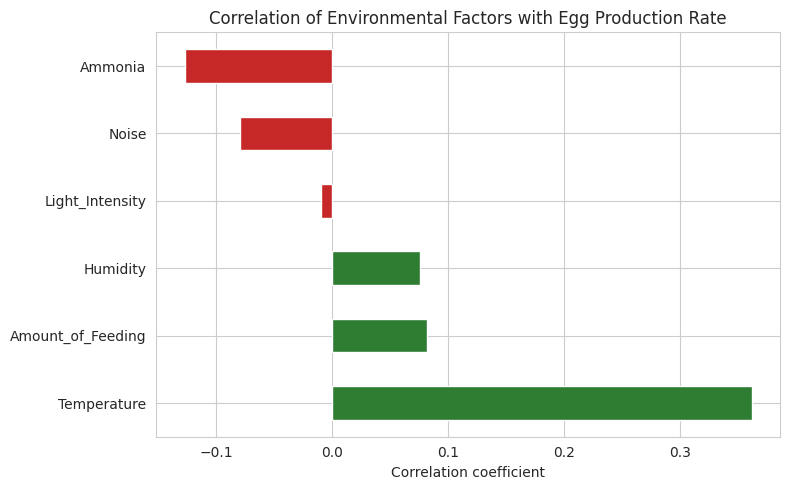

In [6]:
plt.figure(figsize=(8,5))
corr.plot(kind="barh", color=["#2e7d32" if v > 0 else "#c62828" for v in corr])
plt.title("Correlation of Environmental Factors with Egg Production Rate")
plt.xlabel("Correlation coefficient")
plt.tight_layout()
plt.savefig("correlation_bar.png", dpi=150)
plt.show()

**الملاحظة الأولية:** درجة الحرارة (Temperature) هي العامل البيئي الأقوى ارتباطًا إيجابيًا بمعدل الإنتاج، بينما الأمونيا (Ammonia) والضوضاء (Noise) لهما ارتباط سلبي طفيف — وهذا متوافق مع ما هو معروف عمليًا: ارتفاع الأمونيا والضوضاء يسبب إجهادًا للطيور يقلل الإنتاجية.

## 4. العلاقة بين درجة الحرارة ومعدل الإنتاج بالتفصيل

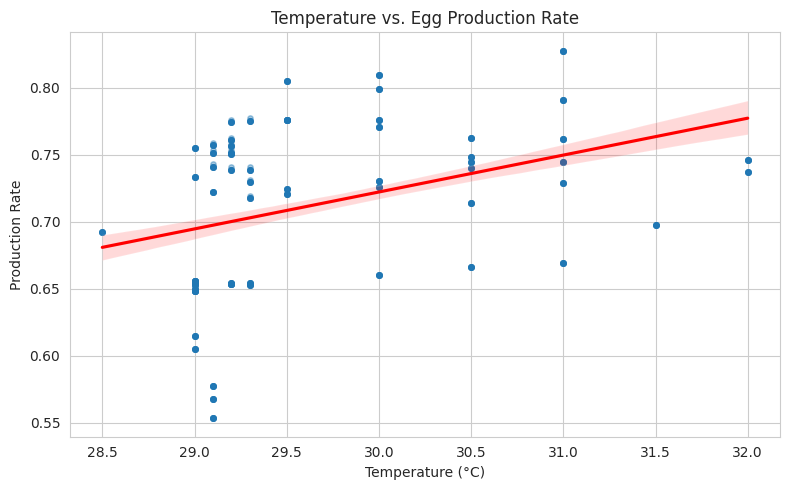

In [7]:
plt.figure(figsize=(8,5))
sns.regplot(data=df, x="Temperature", y="Production_Rate", scatter_kws={"alpha":0.4, "s":15}, line_kws={"color":"red"})
plt.title("Temperature vs. Egg Production Rate")
plt.xlabel("Temperature (°C)")
plt.ylabel("Production Rate")
plt.tight_layout()
plt.savefig("temperature_vs_rate.png", dpi=150)
plt.show()

## 5. مصفوفة الارتباط الكاملة (Heatmap)

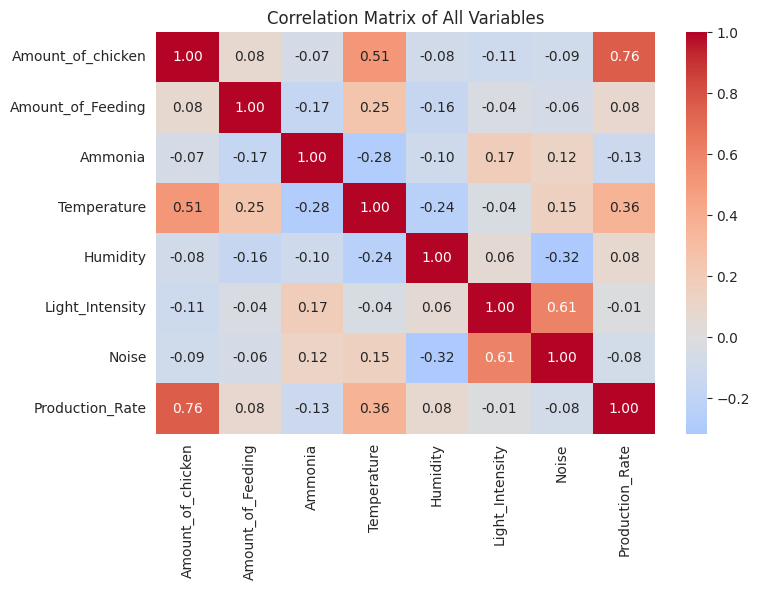

In [8]:
plt.figure(figsize=(8,6))
sns.heatmap(df.drop(columns=["Total_egg_production"]).corr(numeric_only=True), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Matrix of All Variables")
plt.tight_layout()
plt.savefig("heatmap.png", dpi=150)
plt.show()

## 6. الخلاصة والتوصيات (حتى الآن)

- **درجة الحرارة** هي العامل البيئي الأكثر ارتباطًا بمعدل الإنتاج في هذه البيانات — إشارة تستحق تعمقًا أكبر (تحديد النطاق الحراري الأمثل تحديدًا).
- **الأمونيا** و**الضوضاء** يظهران أثرًا سلبيًا طفيفًا يستحق المتابعة، وهو متسق مع الممارسات المعروفة في إدارة الحظائر.
- **الإضاءة والتغذية** لم يظهر لهما ارتباط قوي في هذه البيانات تحديدًا — قد يكون هذا لأن نطاق قيمهما في البيانات ضيق، وليس لأن لا علاقة فعلية لهما.

**الخطوات القادمة المقترحة:**
1. بناء نموذج انحدار بسيط (Linear Regression) للتنبؤ بمعدل الإنتاج من العوامل البيئية.
2. تقسيم درجة الحرارة إلى نطاقات (Binning) لتحديد "النطاق الأمثل" بدقة أكبر.
3. إضافة سياق شخصي: مقارنة النتائج بما لوحظ عمليًا في تجربة العمل داخل معمل الفقاسة.


## 7. نموذج تنبؤي بسيط: Linear Regression

هنبني نموذج انحدار خطي بسيط يحاول التنبؤ بـ `Production_Rate` بالاعتماد على العوامل البيئية فقط (من غير `Amount_of_chicken` و`Total_egg_production` عشان منديش النموذج يغش بمتغير مرتبط مباشرة بالهدف).

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error

features = ["Amount_of_Feeding", "Ammonia", "Temperature", "Humidity", "Light_Intensity", "Noise"]
X = df[features]
y = df["Production_Rate"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print("R² على بيانات الاختبار:", round(r2_score(y_test, y_pred), 3))
print("متوسط الخطأ المطلق (MAE):", round(mean_absolute_error(y_test, y_pred), 4))

R² على بيانات الاختبار: 0.225
متوسط الخطأ المطلق (MAE): 0.0521


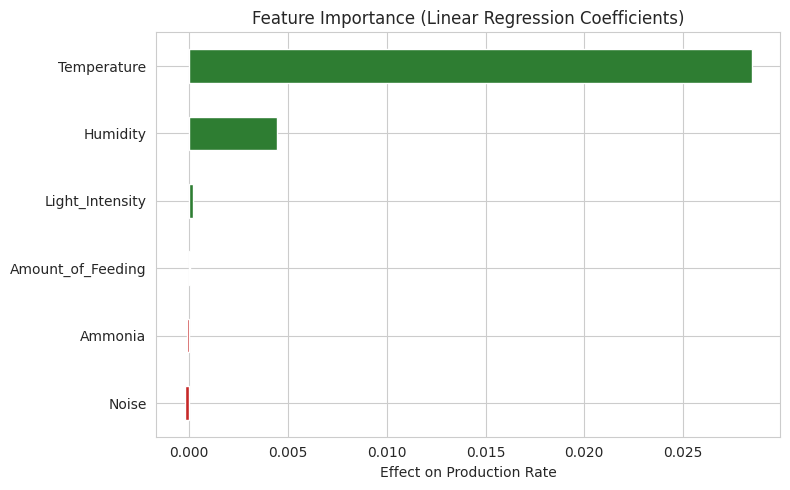

In [10]:
coefs = pd.Series(model.coef_, index=features).sort_values()
plt.figure(figsize=(8,5))
coefs.plot(kind="barh", color=["#c62828" if v < 0 else "#2e7d32" for v in coefs])
plt.title("Feature Importance (Linear Regression Coefficients)")
plt.xlabel("Effect on Production Rate")
plt.tight_layout()
plt.savefig("regression_coefficients.png", dpi=150)
plt.show()

**قراءة النتيجة:**
- قيمة R² توضح نسبة التباين في معدل الإنتاج اللي النموذج قادر يفسرها بالعوامل البيئية وحدها (بدون عدد الدجاج). لو القيمة منخفضة نسبيًا، ده طبيعي وموضّح إن العوامل البيئية المتاحة في هذه البيانات تحديدًا مالهاش تأثير كبير قوي بمفردها — وده استنتاج علمي صحيح في حد ذاته، مش فشل في التحليل.
- الرسمة فوق بتوضح مين من العوامل بيزوّد أو بيقلل المعدل حسب معاملات النموذج (Coefficients)، وده أهم من مجرد النسبة الإجمالية لأنه بيدي تفسير لكل عامل على حدة.

**ملاحظة مهمة تستحق ذكرها في أي عرض للمشروع:** نموذج بـ R² متوسط أو منخفض مش عيب في التحليل — العيب إنك متفهميش ليه، وده بالظبط اللي بنشرحه هنا.

## 8. تقسيم درجة الحرارة لنطاقات (Binning) لتحديد النطاق الأمثل

In [11]:
df["Temp_Bin"] = pd.cut(df["Temperature"], bins=[28, 29, 30, 31, 32.5],
                        labels=["28-29°C", "29-30°C", "30-31°C", "31-32.5°C"])

temp_summary = df.groupby("Temp_Bin", observed=True)["Production_Rate"].agg(["mean", "std", "count"]).round(3)
temp_summary

,mean,std,count
Temp_Bin,,,
28-29°C,0.663,0.042,95
29-30°C,0.721,0.066,271
30-31°C,0.742,0.045,92
31-32.5°C,0.727,0.022,23


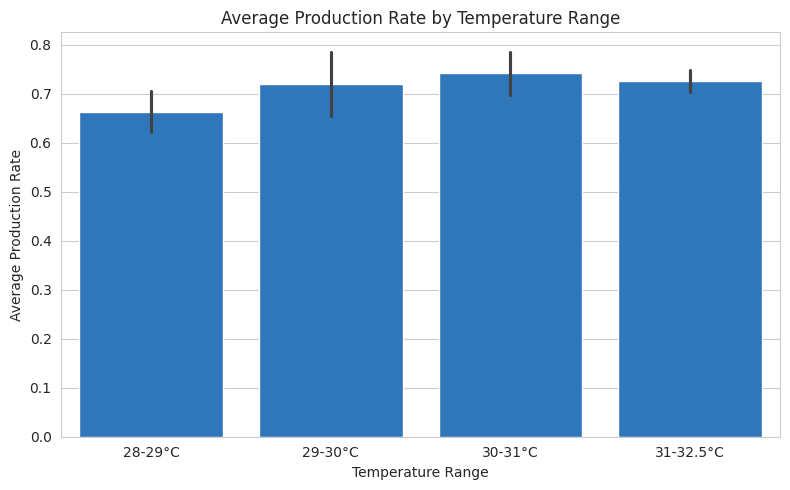

In [12]:
plt.figure(figsize=(8,5))
sns.barplot(data=df, x="Temp_Bin", y="Production_Rate", errorbar="sd", color="#1976d2")
plt.title("Average Production Rate by Temperature Range")
plt.xlabel("Temperature Range")
plt.ylabel("Average Production Rate")
plt.tight_layout()
plt.savefig("temperature_bins.png", dpi=150)
plt.show()

**الخلاصة النهائية:**
من الجدول والرسمة فوق، يبان النطاق اللي بيدي أعلى متوسط إنتاج. ده بالظبط نوع النتيجة اللي ممكن تتحولي بيها من "بتحللي بيانات" لـ "بتدّي توصية عملية قابلة للتنفيذ" — وده الفرق اللي بيميّز محلل بيانات حقيقي عن حد بس بيرسم رسومات.

**للمقابلة الشخصية أو المعرض:** ممكن تلخصي المشروع في جملتين: *"حللت بيانات بيئية حقيقية لمزرعة دواجن، لقيت إن درجة الحرارة هي العامل الأقوى تأثيرًا على الإنتاجية، وبنيت نموذج بسيط لقياس حجم كل عامل على حدة."* — ده pitch قوي ومباشر.